# Task 1: Token-Based Replay Fitness

In [2]:
import pandas as pd
import pm4py
from pm4py.objects.conversion.process_tree import converter as pt_converter

# parse Milestone1 logs
log_clean = pm4py.read_xes("../data/BPI Challenge 2017.xes.gz")
log_noised = pm4py.read_xes("../data/noised.xes.gz")
log_recovered = pm4py.read_xes("../data/recovered.xes.gz")

/Users/yeeyoo/Library/Python/3.9/lib/python/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/Users/yeeyoo/Library/Python/3.9/lib/python/site-packages/pm4py/util/dt_parsing/parser.py:82: UserWarning: ISO8601 strings are not fully supported with strpfromiso for Python versions below 3.11
  warnings.warn(
/Users/yeeyoo/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 31509/31509 [00:52<00:00, 604.98it/s]


In [ ]:
# convert to event_logs
log_clean = pm4py.convert_to_event_log(log_clean)
log_noised = pm4py.convert_to_event_log(log_noised)
log_recovered = pm4py.convert_to_event_log(log_recovered)

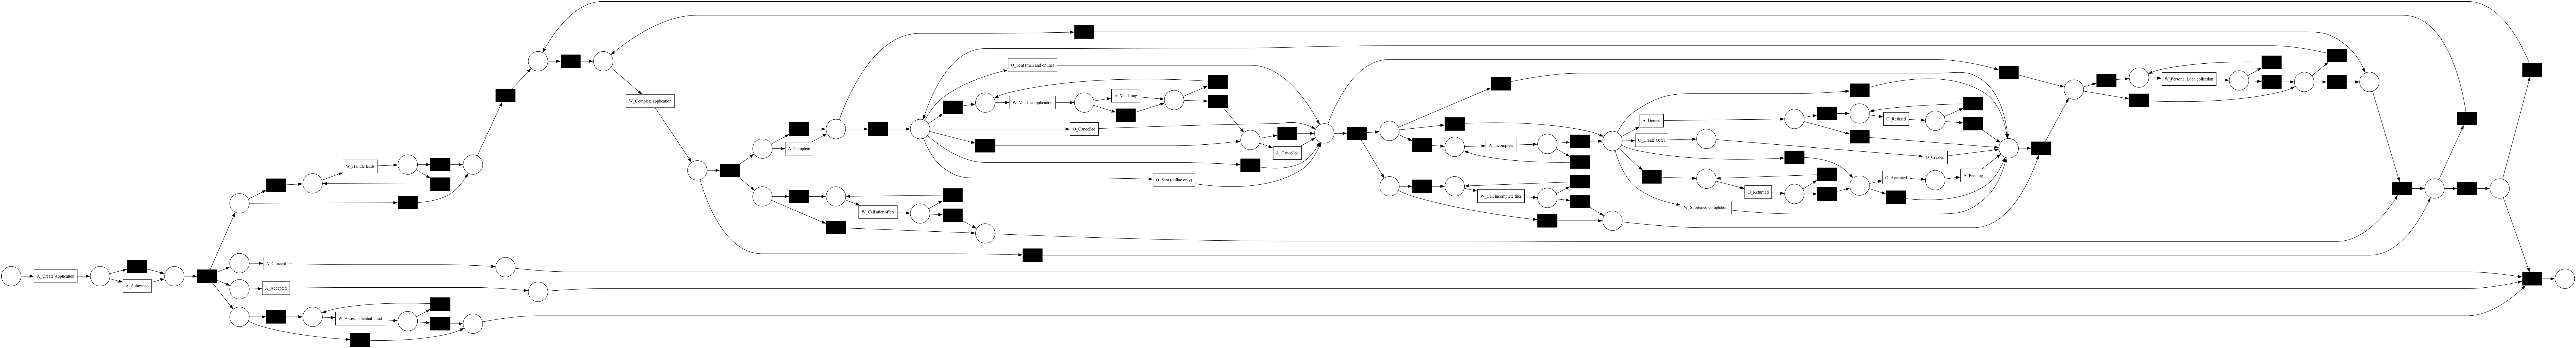

In [50]:
# generate reference model (Inductive Miner on clean_log)
tree_clean= pm4py.discovery.discover_process_tree_inductive(
    log_clean,
    noise_threshold = 0.0
)

reference_model, im, fm = pt_converter.apply(tree_clean)

pm4py.view_petri_net(reference_model)

## a) Replay and score per variant. 
Replay each log on the reference net and record, per trace variant (rows), a table with columns: 
- produced (p)
- consumed (c)
- missing (m)
- remaining (r) 
- and the per-trace fitness. 

In [23]:
from pm4py.algo.conformance.tokenreplay import algorithm as token_replay

In [ ]:
replayed_traces_clean, place_fitness_clean, _, _ = token_replay.apply(
    log_clean,
    reference_model, 
    im, 
    fm, 
    parameters={
        token_replay.Variants.TOKEN_REPLAY.value.Parameters.ENABLE_PLTR_FITNESS: True,
        token_replay.Variants.TOKEN_REPLAY.value.Parameters.DISABLE_VARIANTS: False
    }
)

replaying log with TBR, completed traces :: 100%|██████████| 31509/31509 [12:06<00:00, 43.36it/s]


In [ ]:
replayed_traces_noised, place_fitness_noised, _, _ = token_replay.apply(
    log_noised,
    reference_model, 
    im, 
    fm, 
    parameters={
        token_replay.Variants.TOKEN_REPLAY.value.Parameters.ENABLE_PLTR_FITNESS: True,
        token_replay.Variants.TOKEN_REPLAY.value.Parameters.DISABLE_VARIANTS: False
    }
)

replaying log with TBR, completed traces :: 100%|██████████| 27843/27843 [02:25<00:00, 190.87it/s]


In [ ]:
replayed_traces_recovered, place_fitness_recovered, _, _ = token_replay.apply(
    log_recovered,
    reference_model, 
    im, 
    fm, 
    parameters={
        token_replay.Variants.TOKEN_REPLAY.value.Parameters.ENABLE_PLTR_FITNESS: True,
        token_replay.Variants.TOKEN_REPLAY.value.Parameters.DISABLE_VARIANTS: False
    }
)

replaying log with TBR, completed traces :: 100%|██████████| 16471/16471 [02:58<00:00, 92.26it/s]


In [ ]:
# returns dataframe of all trace variants with replay stats
def variant_replay_table(log, replayed):
    rows = []

    for trace, result in zip(log, replayed):
        variant = ",".join(event["concept:name"] for event in trace)

        rows.append({
            "variant": variant,
            "produced": result["produced_tokens"],
            "consumed": result["consumed_tokens"],
            "missing": result["missing_tokens"],
            "remaining": result["remaining_tokens"],
            "fitness": result["trace_fitness"]
        })

    df = pd.DataFrame(rows)

    # Keep one row per variant
    variant_df = (
        df.groupby("variant")
          .agg({
              "produced": "mean",
              "consumed": "mean",
              "missing": "mean",
              "remaining": "mean",
              "fitness": "mean"
          })
          .reset_index()
    )

    return variant_df

In [31]:
clean_results = variant_replay_table(
    log_clean, replayed_traces_clean
)

clean_results

,variant,produced,consumed,missing,remaining,fitness
0,"A_Create Application,A_Concept,W_Complete appl...",47.0,47.0,0.0,0.0,1.0
1,"A_Create Application,A_Concept,W_Complete appl...",78.0,78.0,0.0,0.0,1.0
2,"A_Create Application,A_Concept,W_Complete appl...",111.0,111.0,0.0,0.0,1.0
3,"A_Create Application,A_Concept,W_Complete appl...",152.0,152.0,0.0,0.0,1.0
4,"A_Create Application,A_Concept,W_Complete appl...",181.0,181.0,0.0,0.0,1.0
...,...,...,...,...,...,...
15925,"A_Create Application,W_Complete application,W_...",172.0,172.0,0.0,0.0,1.0
15926,"A_Create Application,W_Complete application,W_...",145.0,145.0,0.0,0.0,1.0
15927,"A_Create Application,W_Complete application,W_...",234.0,234.0,0.0,0.0,1.0
15928,"A_Create Application,W_Complete application,W_...",288.0,288.0,0.0,0.0,1.0


In [32]:
noised_results = variant_replay_table(
    log_noised, replayed_traces_noised
)

noised_results

,variant,produced,consumed,missing,remaining,fitness
0,A_Create App. - Incident No. Application_17477...,71.0,71.0,1.0,1.0,0.985915
1,A_Create App. - Incident No. Application_18114...,98.0,97.0,2.0,3.0,0.974385
2,"A_Create App.,A_Concept,W_Complete appl.,W_Com...",54.0,54.0,4.0,4.0,0.925926
3,"A_Create App.,A_Concept,W_Complete appl.,W_Com...",69.0,69.0,4.0,4.0,0.942029
4,"A_Create App.,A_Concept,W_Complete appl.,W_Com...",57.0,57.0,3.0,3.0,0.947368
...,...,...,...,...,...,...
27838,"A_Create Application,W_Finish application,W_Fi...",70.0,67.0,3.0,6.0,0.934755
27839,"A_Create Application,W_Finish application,W_Fi...",86.0,83.0,3.0,6.0,0.947044
27840,"A_Create Application,W_Finish application,W_Fi...",49.0,46.0,3.0,6.0,0.906167
27841,"A_Create Application,W_Finish application,W_Fi...",85.0,82.0,3.0,6.0,0.946413


In [33]:
recovered_results = variant_replay_table(
    log_recovered, replayed_traces_recovered
)

recovered_results

,variant,produced,consumed,missing,remaining,fitness
0,"A_Concept,A_Create Application,W_Complete appl...",66.0,65.0,2.0,3.0,0.961888
1,"A_Concept,A_Create Application,W_Complete appl...",115.0,114.0,2.0,3.0,0.978185
2,"A_Concept,A_Create Application,W_Complete appl...",103.0,103.0,3.0,3.0,0.970874
3,"A_Concept,A_Create Application,W_Complete appl...",201.0,201.0,3.0,3.0,0.985075
4,"A_Concept,A_Create Application,W_Complete appl...",243.0,243.0,3.0,3.0,0.987654
...,...,...,...,...,...,...
16466,"A_Create Application,W_Complete application,W_...",58.0,58.0,0.0,0.0,1.000000
16467,"A_Create Application,W_Complete application,W_...",69.0,68.0,1.0,2.0,0.978154
16468,"A_Create Application,W_Complete application,W_...",203.0,203.0,1.0,1.0,0.995074
16469,"A_Create Application,W_Complete application,W_...",155.0,155.0,2.0,2.0,0.987097


In [34]:
# export the per-variant tables
clean_results.to_csv("../data/milestone3/tbr_per_variant_fitness_clean.csv", index=False)
noised_results.to_csv("../data/milestone3/tbr_per_variant_fitness_noised.csv", index=False)
noised_results.to_csv("../data/milestone3/tbr_per_variant_fitness_recovered.csv", index=False)

## b) Aggregate per log

For each log, report the 
- overall fitness (token counts pooled across all cases)
- proportion ofcases that replay perfectly (m = r = 0) 
  
in a table with the three logs as rows.

In [ ]:
# returns metrics (pooled fitness & ratio of perfect traces) for given log
def log_level_metrics(replayed, name):

    total_p = 0
    total_c = 0
    total_m = 0
    total_r = 0

    perfect_cases = 0
    n_cases = len(replayed)

    for result in replayed:

        p = result["produced_tokens"]
        c = result["consumed_tokens"]
        m = result["missing_tokens"]
        r = result["remaining_tokens"]

        total_p += p
        total_c += c
        total_m += m
        total_r += r

        if m == 0 and r == 0:
            perfect_cases += 1

    # pooled fitness
    fitness = 0.5 * (1 - total_m / total_c) + \
              0.5 * (1 - total_r / total_p)

    return {
        "log": name,
        "fitness": fitness,
        "perfect_case_ratio": perfect_cases / n_cases
    }

In [49]:
results = []

results.append(log_level_metrics(replayed_traces_clean, "clean"))
results.append(log_level_metrics(replayed_traces_noised, "noised"))
results.append(log_level_metrics(replayed_traces_recovered, "recovered"))

df = pd.DataFrame(results)[
    ["log", "fitness", "perfect_case_ratio"]
]

df

,log,fitness,perfect_case_ratio
0,clean,1.000000,1.000000
1,noised,0.986845,0.442858
2,recovered,0.987008,0.022343


## c) Locate hotspots. 

For each log, 
- sum the missing and remaining tokens per place across all cases
- report the top five places by total in a short table: 
  - rows are hotspots, columns are 
  - 1) place (with adjacent activity), 
  - 2) missing tokens, 
  - 3) remaining tokens.

In [ ]:
# returns top5 hotspot places (with adjacent activity) with missing/remaining token count as dataframe
def hotspot_analysis(place_fitness):
    rows = []

    for place, stats in place_fitness.items():

        # get activity names before and after transition to determine adjacent activity
        after = [arc.target.label for arc in place.out_arcs if arc.target.label]
        before = [arc.source.label for arc in place.in_arcs if arc.source.label]

        adjacent = (
            after[0] if len(after) > 0
            else before[0] if len(before) > 0
            else "—"
        )

        rows.append({
            "place": place,
            "adjacent": adjacent,
            "missing tokens": stats["m"],
            "remaining tokens": stats["r"],
            "total": stats["m"] + stats["r"]
        })

    df = pd.DataFrame(rows)

    return (
        df.sort_values("total", ascending=False)
          .head(5)
          .reset_index(drop=True)
    )

In [39]:
hotspot_analysis(place_fitness_clean)

,place,adjacent,missing tokens,remaining tokens,total
0,sink,—,0,0,0
1,p_31,A_Complete,0,0,0
2,p_63,A_Pending,0,0,0
3,p_7,A_Accepted,0,0,0
4,p_28,W_Call after offers,0,0,0


In [38]:
hotspot_analysis(place_fitness_noised)

,place,adjacent,missing tokens,remaining tokens,total
0,p_31,A_Complete,9189,0,9189
1,p_49,A_Pending,0,7728,7728
2,p_46,W_Call incomplete files,0,5164,5164
3,sink,—,4075,0,4075
4,p_54,O_Created,2021,2048,4069


In [40]:
hotspot_analysis(place_fitness_recovered)

,place,adjacent,missing tokens,remaining tokens,total
0,p_63,A_Pending,11070,17071,28141
1,p_31,A_Complete,15324,0,15324
2,p_40,A_Validating,0,13616,13616
3,p_49,A_Pending,0,13057,13057
4,p_43,—,0,8936,8936


## d) Compare and conclude. 

Can the overall token fitness be trusted when it stays high but few cases fit perfectly? On the
noised log, contrast the two figures from b), explain the gap, and judge how far token-based replay alone can support an
audit verdict.

### Answer

No, a high overall fitness score can't be trusted to determine if a process is well-fitting if few cases fit perfectly

for the noised log:
- high fitness: 0.986845
- low-medium ratio of fitting cases 0.442858

Surpisingly, the perfect case ratio still is higher than expected on the noised log. Almost half of the traces were perfectly fitting.

The gap exists because global fitness calculates the sum of missing and remaining tokens in relation to the sum of produced/consumed tokens. In contrast, perfect case ratio measures case-level correctness and is strict to any small deviations of a trace to the process model

For an audit verdict, token based replay is good as an rough measure on whether the model explains the log behavior, and as an entry point to more detailed trace-variant analysis to identify hotspots. But only looking at the overall fitness can be misleading. 

The interpretation also depends on the goal of the conformance checking. To test a discovered process model or an best-case handbook process model and see where everyday practice deviates. 
